In [1]:
import os
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [ ]:
import psutil

# Get the current CPU affinity for your process
current_affinity = psutil.Process().cpu_affinity()

# Display the current CPU affinity
print("Current CPU Affinity:", current_affinity)

In [ ]:

# Get the current CPU affinity for your process
current_affinity = psutil.Process().cpu_affinity()

# Display the current CPU affinity
print("Current CPU Affinity:", current_affinity)

# Set the new CPU affinity (using only the first four cores)
new_affinity = [0, 1, 2, 3, 4, 5, 6]
psutil.Process().cpu_affinity(new_affinity)

# Display the updated CPU affinity
updated_affinity = psutil.Process().cpu_affinity()
print("Updated CPU Affinity:", updated_affinity)

# Rest of your code for model training...


Found 12252 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.
Epoch 1/20
382/382 [==============================] - 1055s 3s/step - loss: 2.2773 - accuracy: 0.3113 - val_loss: 1.5193 - val_accuracy: 0.4360
Epoch 2/20
382/382 [==============================] - 1006s 3s/step - loss: 1.8405 - accuracy: 0.4004 - val_loss: 1.4046 - val_accuracy: 0.4887
Epoch 3/20
382/382 [==============================] - 985s 3s/step - loss: 1.6294 - accuracy: 0.4536 - val_loss: 1.3185 - val_accuracy: 0.5285
Epoch 4/20
382/382 [==============================] - 956s 3s/step - loss: 1.4632 - accuracy: 0.5047 - val_loss: 1.1218 - val_accuracy: 0.6102
Epoch 5/20
382/382 [==============================] - 910s 2s/step - loss: 1.3255 - accuracy: 0.5505 - val_loss: 1.1246 - val_accuracy: 0.5913
Epoch 6/20
382/382 [==============================] - 1671s 4s/step - loss: 1.2567 - accuracy: 0.5742 - val_loss: 1.1649 - val_accuracy: 0.6083
Epoch 7/20
382/382 [==============================] - 

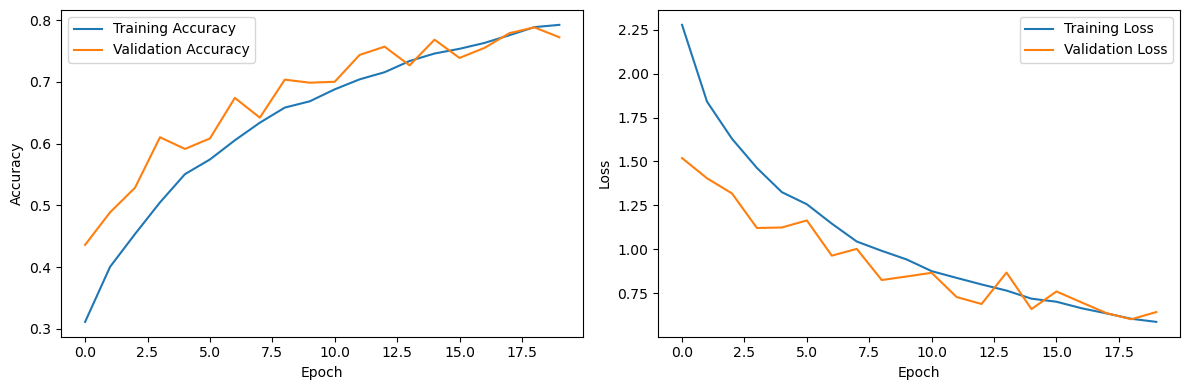

C:\Users\Sandusha\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [12]:

# Constants
IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 20
BAT_SIZE = 32
NUM_CLASSES = 7  # Number of snake classes

# Dataset folders
dataset_folder = "D:\\DatasetNew"
train_dir = "D:\\DatasetNew\\train"
val_dir = "D:\\DatasetNew\\val"
test_dir = "D:\\DatasetNew\\test"

# Build the CNN model
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(IM_WIDTH, IM_HEIGHT, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dropout(0.5))  # Increased dropout for regularization
model.add(Dense(256, activation='relu'))  # Increased number of neurons
model.add(BatchNormalization())
model.add(Dropout(0.5))  # Additional dropout
model.add(Dense(NUM_CLASSES, activation='softmax'))

# Compile the model with Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
        rotation_range=30,  # Rotate images randomly up to 90 degrees # Flip images horizontally
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        fill_mode='nearest',
)

val_datagen = ImageDataGenerator(
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        shear_range=0.2,
        zoom_range=0.2,
        fill_mode='nearest',                  
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IM_WIDTH, IM_HEIGHT),
    batch_size=BAT_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IM_WIDTH, IM_HEIGHT),
    batch_size=BAT_SIZE,
    class_mode='categorical'
)

# Use EarlyStopping callback during training
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BAT_SIZE,
    epochs=NB_EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BAT_SIZE,
    callbacks=[early_stopping]
)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save the model
model.save("snake_breed_model1.h5")
